In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Twitter_Data.csv.zip to Twitter_Data.csv.zip


In [ ]:
import zipfile
import os

zip_path = "Twitter_Data.csv.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print(os.listdir("dataset"))

['Twitter_Data.csv']


In [ ]:
df = pd.read_csv("dataset/Twitter_Data.csv")

In [ ]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nCategory Counts:")
print(df['category'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB
None

Missing Values:
clean_text    4
category      7
dtype: int64

Category Counts:
category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64


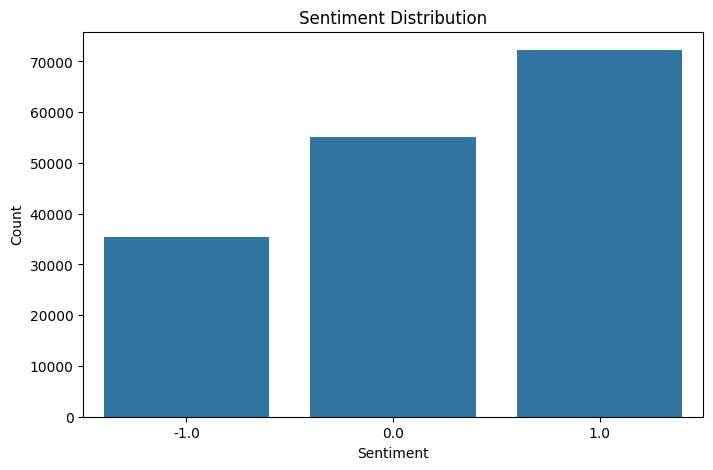

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='category',
    data=df
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [ ]:
print(df['clean_text'].isnull().sum())
print(df['clean_text'].dtype)

df['clean_text'] = df['clean_text'].fillna('')
df['text_length'] = df['clean_text'].astype(str).apply(len)

df.info()
df.head()

0
object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   clean_text   162980 non-null  object 
 1   category     162973 non-null  float64
 2   text_length  162980 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 3.7+ MB


,clean_text,category,text_length
0,when modi promised “minimum government maximum...,-1.0,210
1,talk all the nonsense and continue all the dra...,0.0,68
2,what did just say vote for modi welcome bjp t...,1.0,117
3,asking his supporters prefix chowkidar their n...,1.0,212
4,answer who among these the most powerful world...,1.0,81


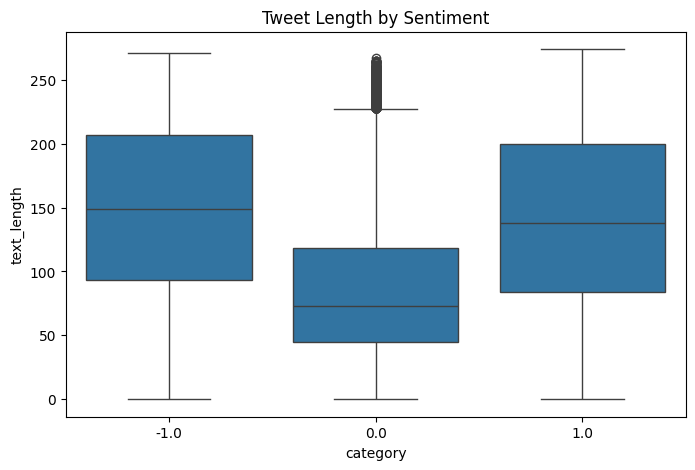

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='category',
    y='text_length',
    data=df
)

plt.title("Tweet Length by Sentiment")
plt.show()

In [ ]:
X = df['clean_text']
y = df['category']

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(df['category'].isnull().sum())

7


In [ ]:
df = df.dropna(subset=['clean_text', 'category'])

print(df.isnull().sum())

clean_text     0
category       0
text_length    0
dtype: int64


In [36]:
X = df['clean_text']
y = df['category']

X_tfidf = tfidf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, nb_pred))

Accuracy: 0.7071943549624176


In [39]:
print(classification_report(
    y_test,
    nb_pred
))
print(classification_report(
    y_test,
    nb_pred
))

              precision    recall  f1-score   support

        -1.0       0.87      0.45      0.59      7230
         0.0       0.78      0.64      0.71     10961
         1.0       0.64      0.89      0.75     14404

    accuracy                           0.71     32595
   macro avg       0.77      0.66      0.68     32595
weighted avg       0.74      0.71      0.70     32595

              precision    recall  f1-score   support

        -1.0       0.87      0.45      0.59      7230
         0.0       0.78      0.64      0.71     10961
         1.0       0.64      0.89      0.75     14404

    accuracy                           0.71     32595
   macro avg       0.77      0.66      0.68     32595
weighted avg       0.74      0.71      0.70     32595



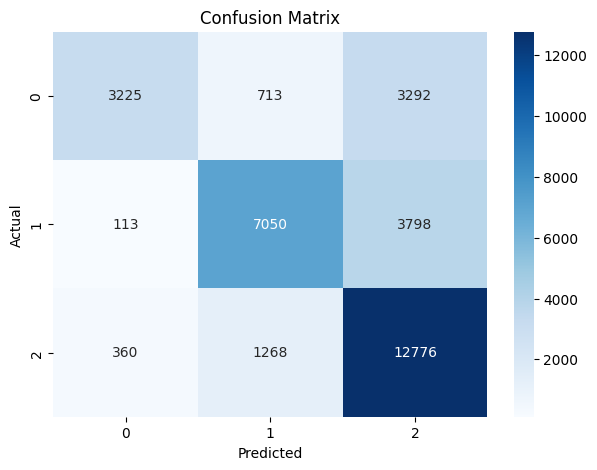

In [40]:
cm = confusion_matrix(
    y_test,
    nb_pred
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [41]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

Accuracy: 0.8530756250958736


In [42]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, svm_pred))

Accuracy: 0.8604387175947231


In [43]:
results = pd.DataFrame({
    "Model":[
        "Naive Bayes",
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy":[
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

print(results)

                 Model  Accuracy
0          Naive Bayes  0.707194
1  Logistic Regression  0.853076
2                  SVM  0.860439


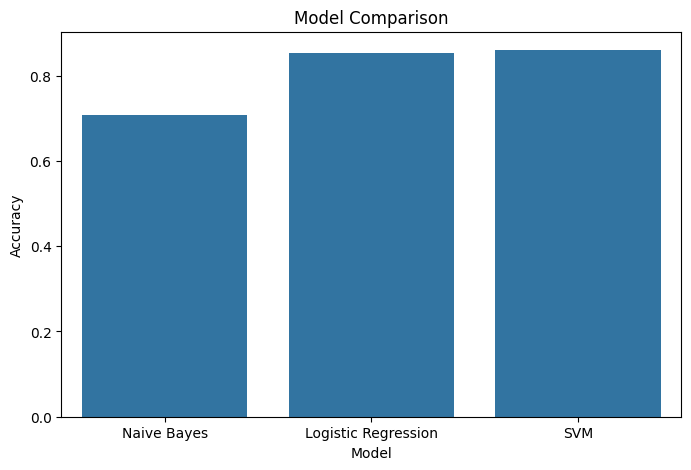

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Model Comparison")
plt.show()

In [45]:
sample = [
    "I love this product",
    "This is terrible",
    "The service is okay"
]

sample_vector = tfidf.transform(sample)

prediction = svm_model.predict(sample_vector)

for tweet, pred in zip(sample, prediction):

    if pred == 1:
        sentiment = "Positive"

    elif pred == 0:
        sentiment = "Neutral"

    else:
        sentiment = "Negative"

    print(tweet, "->", sentiment)

I love this product -> Positive
This is terrible -> Negative
The service is okay -> Positive
